# ALUNOS:
- Vasco Alves - nº estudante 2022228207

# OBJECTIVO
Este projeto visa a análise nos domínios da frequência
e do tempo de sinais áudio com o objetivo de identificar os dígitos
em inglês entre 0 e 9. 

# DESCRIÇÃO DOS DADOS:
Os dados fornecidos correspondem a sinais de voz emitidos
por 60 participantes (cada uma das subdiretorias na pasta data contém os sinais
correspondentes a 1 participante). Cada participante repetiu 50 vezes cada um
dos dígitos, ou seja, cada uma das 60 pastas contém 500 sinais de áudio em
formato ‘.wav’. Cada sinal de áudio foi adquirido a uma taxa de amostragem
de 48000 Hz em modo mono-canal. Mais detalhes sobre os dados podem ser
obtidos nas ligações seguintes.  
- https://github.com/soerenab/AudioMNIST 
- https://www.kaggle.com/datasets/sripaadsrinivasan/audio-mnist 
- https://arxiv.org/abs/1807.03418.  

# ENTREGAS:
- Meta 1: 09/abr/2026, 23:59 
- Meta 2: 14/mai/2026, 23:59 


In [6]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy
from scipy.io import wavfile
import os
import random
print("Feito")

Feito


# Meta 1 Análise Temporal e de Frequência 

## Exercicio 1
Crie uma estrutura de dados (por exemplo, uma tabela) e guarde as seguintes informações relativas a cada áudio: 

- a. diretório do áudio; 
- b. nome do ficheiro (com extensão); 
- c. participante; 
- d. dígito; 
- e. número da repetição. 

In [2]:
# a pasta 'data' deve estar na mesma pasta que o notebook
pastas = [d for d in os.listdir('data') if os.path.isdir(os.path.join('data', d))]
mega_dados_xpto = []
for p in pastas:
    caminho_pasta = os.path.join('data', p)
    # ficheiros .wav dentro de cada pasta de participante
    ficheiros = [f for f in os.listdir(caminho_pasta) if f.endswith('.wav')]
    for f in ficheiros:
        # nome do ficheiro: -> digito_participante_repeticao.wav 
        # removemos a extensão .wav e dividimos pelo underscore
        # para obter os dados
        nome_sem_extensao = f.replace('.wav', '')
        partes = nome_sem_extensao.split('_')
        if len(partes) == 3:
            digito, participante, repeticao = partes
            mega_dados_xpto.append([p, f, int(participante), int(digito), int(repeticao)])

# Eu gosto de DataFrames
cols = ["dir", "nome", "participante", "digito", "repeticao"]
dados_df = pd.DataFrame(mega_dados_xpto, columns=cols)

# Se o número de registos não for 30000, está errado
assert(len(dados_df) == 60 * 50 * 10)
print(f"Total de registos: {len(dados_df)}")
print(dados_df.head())

Total de registos: 30000
  dir         nome  participante  digito  repeticao
0  01   0_01_0.wav             1       0          0
1  01   0_01_1.wav             1       0          1
2  01  0_01_10.wav             1       0         10
3  01  0_01_11.wav             1       0         11
4  01  0_01_12.wav             1       0         12


## Exercicio 2
Desenvolva código para importação dos sinais de áudio e guarde o valor da taxa de amostragem e os sinais na estrutura de dados criada no ponto 1. Nota: pode utilizar a função audioread do MATLAB. 

In [4]:
# novas colunas vazias
dados_df['signal'] = None
dados_df['sampling_rate'] = None
for idx, row in dados_df.iterrows():
    caminho_completo = os.path.join('data', row['dir'], row['nome'])  
    try:
        sr, signal = wavfile.read(caminho_completo)
        dados_df.at[idx, 'signal'] = signal
        dados_df.at[idx, 'sampling_rate'] = sr      
    except Exception as e:
        print(f"wav não existe?? - {caminho_completo} - {e}")
print("Colunas adicionadas com sucesso!")
print(dados_df[['nome', 'sampling_rate']].head())

Colunas adicionadas com sucesso!
          nome sampling_rate
0   0_01_0.wav         48000
1   0_01_1.wav         48000
2  0_01_10.wav         48000
3  0_01_11.wav         48000
4  0_01_12.wav         48000


## Exercicio 3
Reproduza e represente graficamente um exemplo dos sinais importados, identificando o dígito e o número da repetição a que cada um corresponde, e indicando o eixo horizontal com o tempo em segundos, como apresentado no exemplo da Figura 2.  

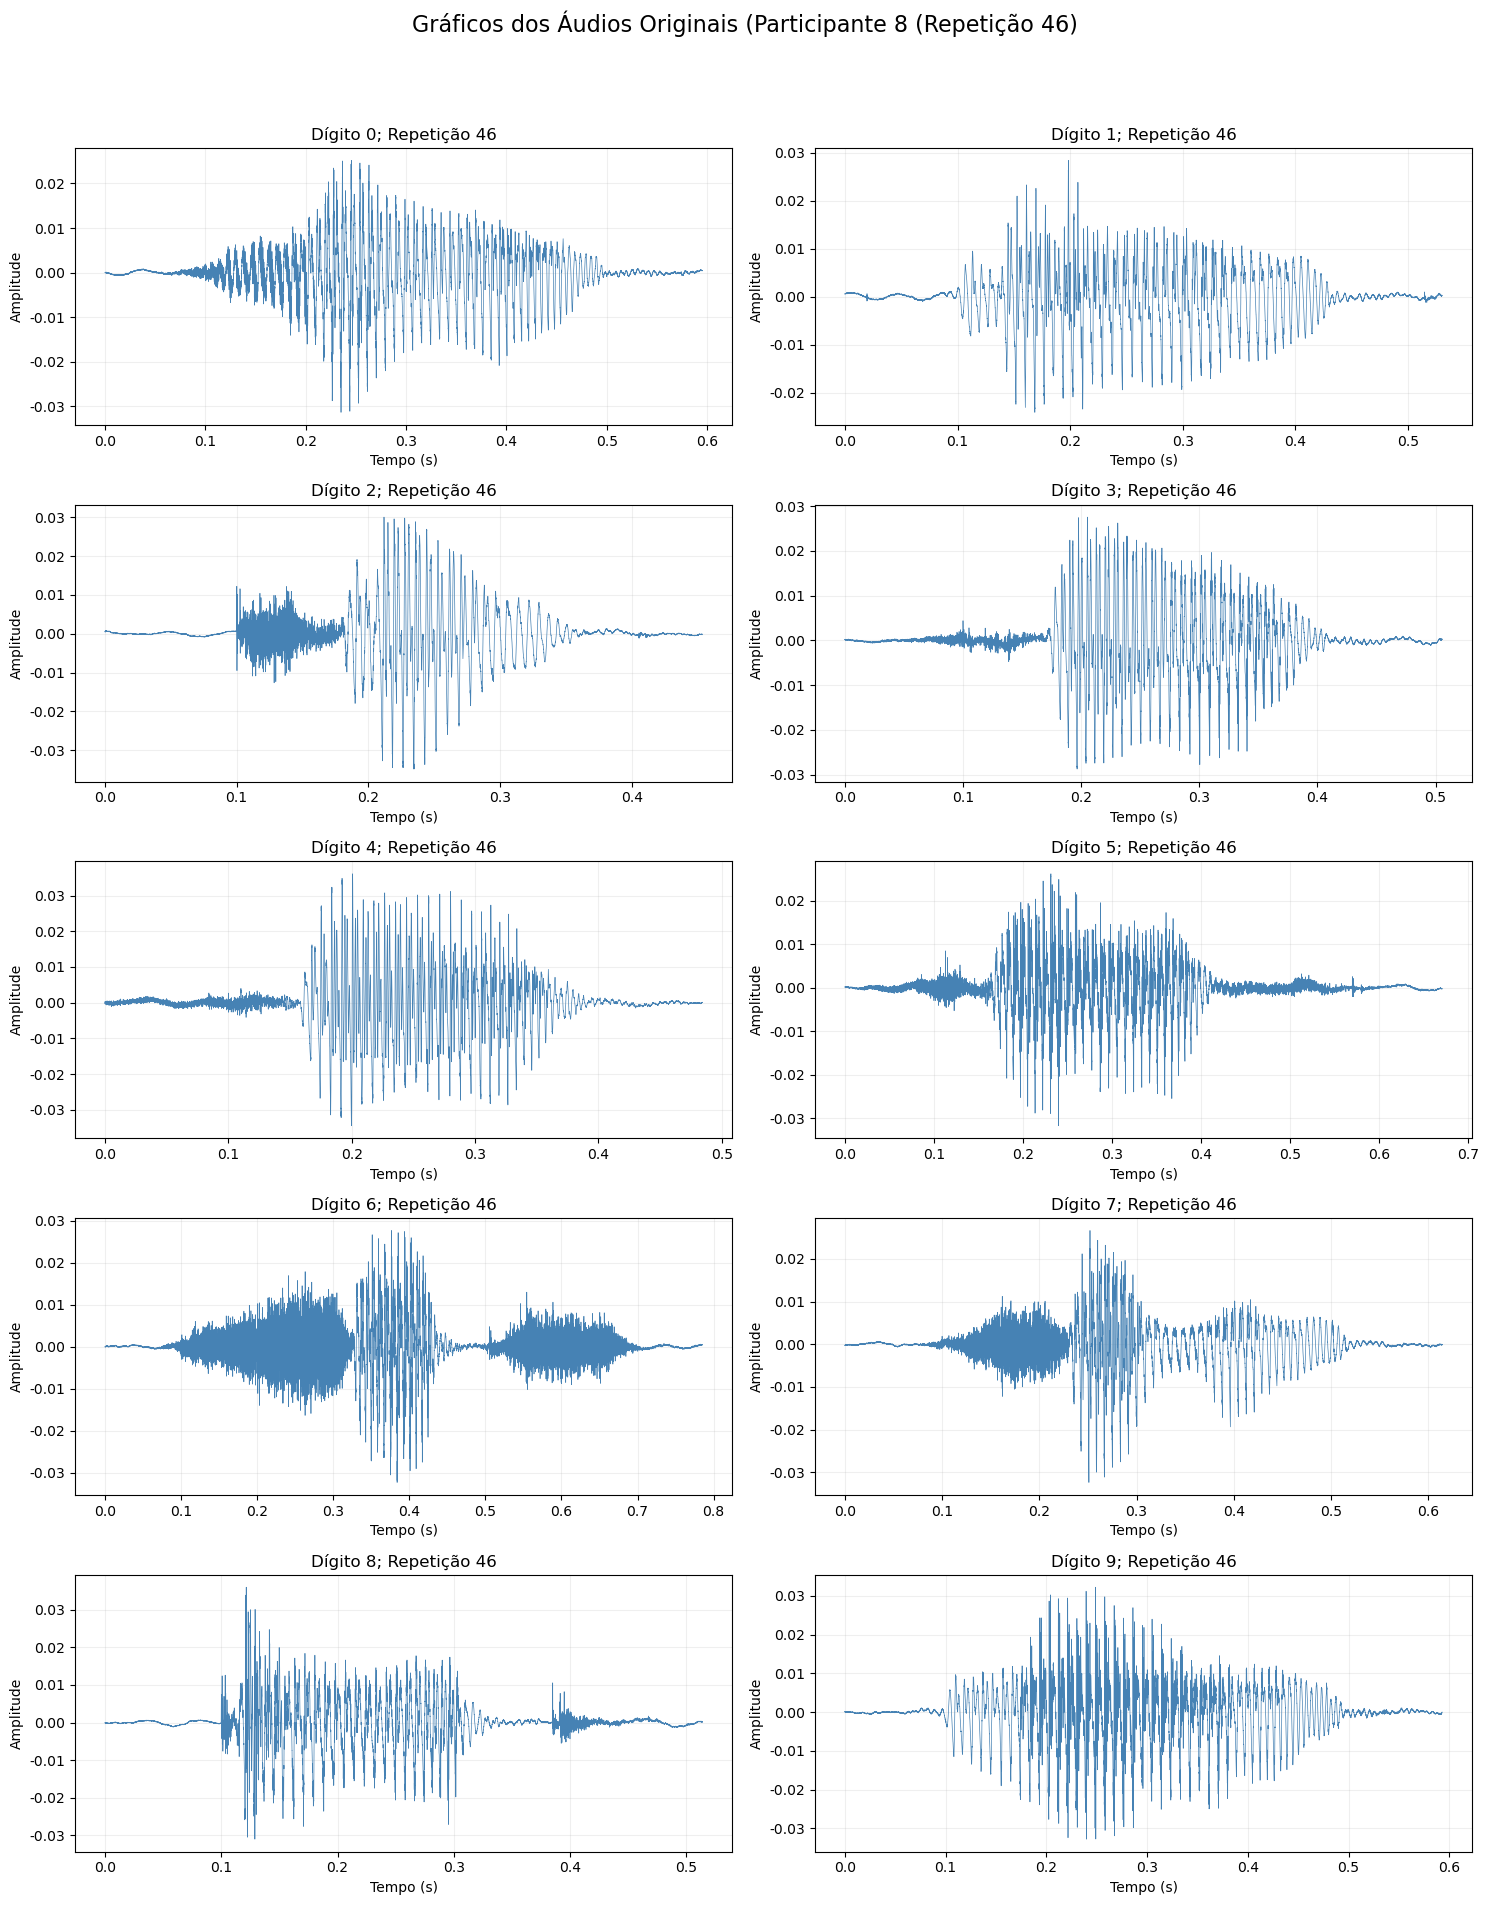

In [29]:
from matplotlib.ticker import FormatStrFormatter
# escolher um participante e uma repeticao aleatoriamente
sujeito_aleatorio = random.choice(dados_df['participante'].unique())
rep_aleatoria = random.choice(dados_df['repeticao'].unique())

# criar a figura com 5 linhas e 2 colunas
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle(f'Gráficos dos Áudios Originais (Participante {sujeito_aleatorio} (Repetição {rep_aleatoria})', fontsize=16)

# iterar pelos digitos de 0 a 9
for digito in range(10):
    selecao = dados_df[(dados_df['participante'] == sujeito_aleatorio) & 
                      (dados_df['repeticao'] == rep_aleatoria) & 
                      (dados_df['digito'] == digito)]
    
    if not selecao.empty:
        # NOTE(vasco): o formato wav vem em inteiros de 16 bits
        # é necessario converter para floats para ficar
        # como está na figura
        sinal = selecao.iloc[0]['signal'] / pow(2, 15) # 15 porque sao inteiros positivos
        sr = selecao.iloc[0]['sampling_rate']
        
        # calcular o vetor de tempo em segundos
        tempo = np.linspace(0, len(sinal) / sr, num=len(sinal))
        ax = axes[digito // 2, digito % 2]
        
        # plot do sinal
        ax.plot(tempo, sinal, color='steelblue', linewidth=0.5)
        ax.set_title(f'Dígito {digito}; Repetição {rep_aleatoria}')
        ax.set_xlabel('Tempo (s)')
        ax.set_ylabel('Amplitude')
        # eu queria que fosse exatamente igual à imagem!!!
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.grid(alpha=0.2)

# ajustar o layout para nao sobrepor titulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exercicio 4
Uma estratégia que pode melhorar a diferenciação entre dígitos é fazer uma etapa de pré-processamento para garantir que todos os ficheiros têm a mesma duração e intervalo de amplitude. 

Para isso deverá implementar os seguintes passos:

- Retirar o “silêncio” inicial dos sinais, de forma a garantir que todos começam exatamente ao mesmo tempo (por exemplo, através do estudo da Energia do sinal ao longo do tempo). 
- Normalizar a amplitude com base na amplitude máxima e mínima das amostras. Isto garante que os problemas usuais da gravação do som (por exemplo, a distância da pessoa ao microfone) não interferem na análise. 
- Adicionar (ou retirar) silêncio no fim dos ficheiros para garantir que todos têm a mesma duração total.

Guarde os sinais após o pré-processamento na estrutura de dados criada no ponto 1. 

In [ ]:
def preprocessamento(signal, sr, target_dur=1.0):
    # retirar o silêncio inicial baseado na energia
    # calculamos a energia em janelas pequenas
    window_size = int(sr * 0.02) # janelas de 20ms
    energy = np.array([
        np.sum(signal[i:i+window_size]**2) 
        for i in range(0, len(signal), window_size)
    ])
    
    # definimos um threshold (ex: 5% da energia máxima)
    threshold = 0.05 * np.max(energy)
    
    # encontrar o primeiro bloco que ultrapassa o threshold
    start_index = 0
    for i, e in enumerate(energy):
        if e > threshold:
            start_index = i * window_size
            break
            
    # cortamos o sinal desde o início do som
    trimmed_signal = signal[start_index:]
    
    # normalizar a amplitude (min-max para o intervalo [-1, 1])
    # primeiro convertemos para float se ainda não for
    trimmed_signal = trimmed_signal.astype(np.float32)
    
    max_val = np.max(np.abs(trimmed_signal))
    if max_val > 0:
        normalized_signal = trimmed_signal / max_val
    else:
        normalized_signal = trimmed_signal

    # ajustar a duração (padding ou cropping no fim)
    target_samples = int(target_dur * sr)
    current_samples = len(normalized_signal)
    
    if current_samples > target_samples:
        # se for maior, cortamos o fim
        final_signal = normalized_signal[:target_samples]
    else:
        # se for menor, adicionamos silêncio (zeros) no fim
        padding = np.zeros(target_samples - current_samples)
        final_signal = np.concatenate((normalized_signal, padding))
        
    return final_signal

# duraçao ideal de 1 segundo (arbitrario)
duracao_ideal = 1.0
dados_df['signal_preproc'] = dados_df.apply(
    lambda row: preprocessamento(row['signal'], row['sampling_rate'], duracao_ideal), 
    axis=1
)